In [35]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [36]:
ALLPIX_FILE   = "allpix150V.csv"
GARFIELD_FILE = "garfield150V.csv"
SILVACO_FILE  = "silvaco150V.csv"

In [37]:
GARFIELD_CURVE = "i_gainON"
SILVACO_WIDTH_UM = 1.0

In [38]:
def load_allpix(path, col):
    allpix = np.genfromtxt(path, delimiter=",", names=True)
    (allpix.dtype.names)
    print(allpix.dtype.names)
    return allpix["t_ns"], allpix[col] # already ns / uA
    # t = allpix["t_ns"]
    # i = allpix[col] * 1e1
    # return t, i
 
def load_garfield(path, col):
    garfield = np.genfromtxt(path, delimiter=",", names=True)
    (garfield.dtype.names)
    print(garfield.dtype.names)
    return garfield["t_ns"], garfield[col] # fC/ns == uA
 
def load_silvaco(path, width_um):
    silvaco = np.genfromtxt(path, delimiter=",", names=True)
    print(silvaco.dtype.names)
    t_ns = silvaco["Transient_time"] * 1e9 # s -> ns
    i_uA = silvaco["Anode_Current"] * 1e6 * width_um   # A/um -> uA
    fired = np.abs(i_uA) > 10 * np.abs(i_uA[0])
    baseline = i_uA[~fired].mean() if (~fired).any() else 0.0
    return t_ns, -(i_uA - baseline)
 
curves = {}
# t, i = load_allpix(ALLPIX_FILE, "both_raw_uA")
# curves["Allpix (pad, low-pass)"] = (t, i, "tab:green")
t, i = load_garfield(GARFIELD_FILE, GARFIELD_CURVE)
curves[f"Garfield++ ({GARFIELD_CURVE})"] = (t, i, "tab:red")
t, i = load_silvaco(SILVACO_FILE, SILVACO_WIDTH_UM)
curves["Silvaco (anode, sign-flipped)"] = (t, i, "tab:blue")
 
# collected charge: uA x ns = fC, directly comparable across simulators
_trap = getattr(np, "trapezoid", None) or np.trapz
print(f"{'curve':35s} {'peak [uA]':>12s} {'charge [fC]':>12s}")
for name, (t, i, c) in curves.items():
    print(f"{name:35s} {i[np.argmax(np.abs(i))]:12.3f} "
          f"{_trap(i, t):12.3f}")


('bin', 't_ns', 'i_gainON', 'i_gainOFF')
('Transient_time', 'Anode_Voltage', 'Anode_Int_Voltage', 'Anode_Current', 'Cathode_Voltage', 'Cathode_Int_Voltage', 'Cathode_Current', 'Substrate_Voltage', 'Substrate_Int_Voltage', 'Substrate_Current', 'SEU_Track_Charge', 'SEU_Track_Cumulative_Charge', 'SEU_Track_Generation_Rate')
curve                                  peak [uA]  charge [fC]
Garfield++ (i_gainON)                     -7.347       -6.716
Silvaco (anode, sign-flipped)             -4.987       -4.586


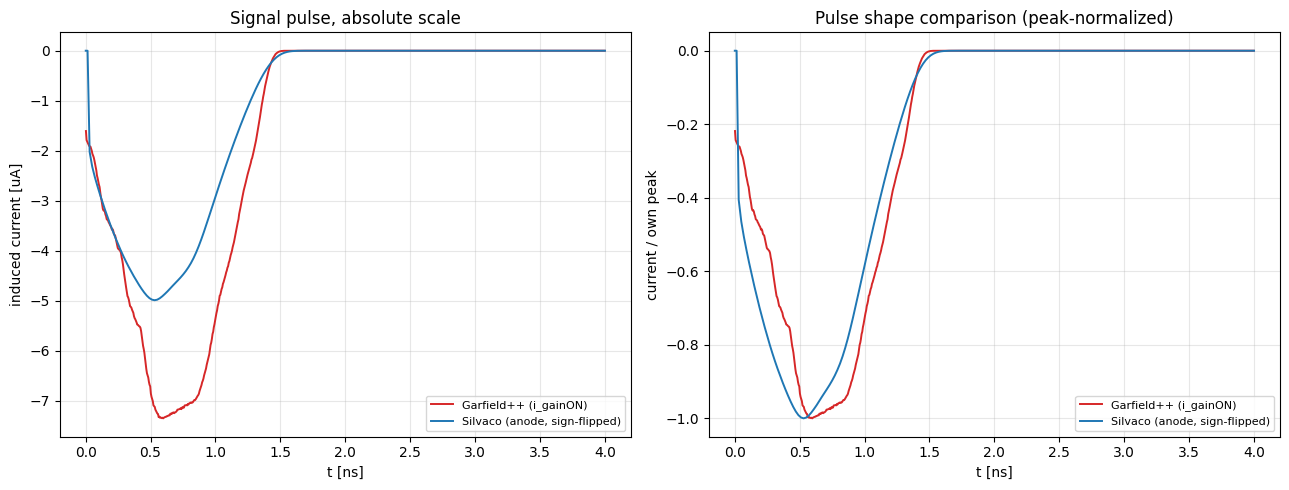

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
ax = axes[0]
for name, (t, i, c) in curves.items():
    ax.plot(t, i, color=c, lw=1.4, label=name)
ax.set_xlabel("t [ns]")
ax.set_ylabel("induced current [uA]")
ax.set_title("Signal pulse, absolute scale")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
for name, (t, i, c) in curves.items():
    peak = np.max(np.abs(i))
    ax.plot(t, i / peak if peak > 0 else i, color=c, lw=1.4, label=name)
ax.set_xlabel("t [ns]")
ax.set_ylabel("current / own peak")
ax.set_title("Pulse shape comparison (peak-normalized)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig("signal_comparison.png", dpi=150)
plt.show()


In [40]:
df = pd.read_csv("wfield_full.csv")

x = np.sort(df["x_um"].unique())
y = np.sort(df["y_um"].unique())
X, Y = np.meshgrid(x, y)

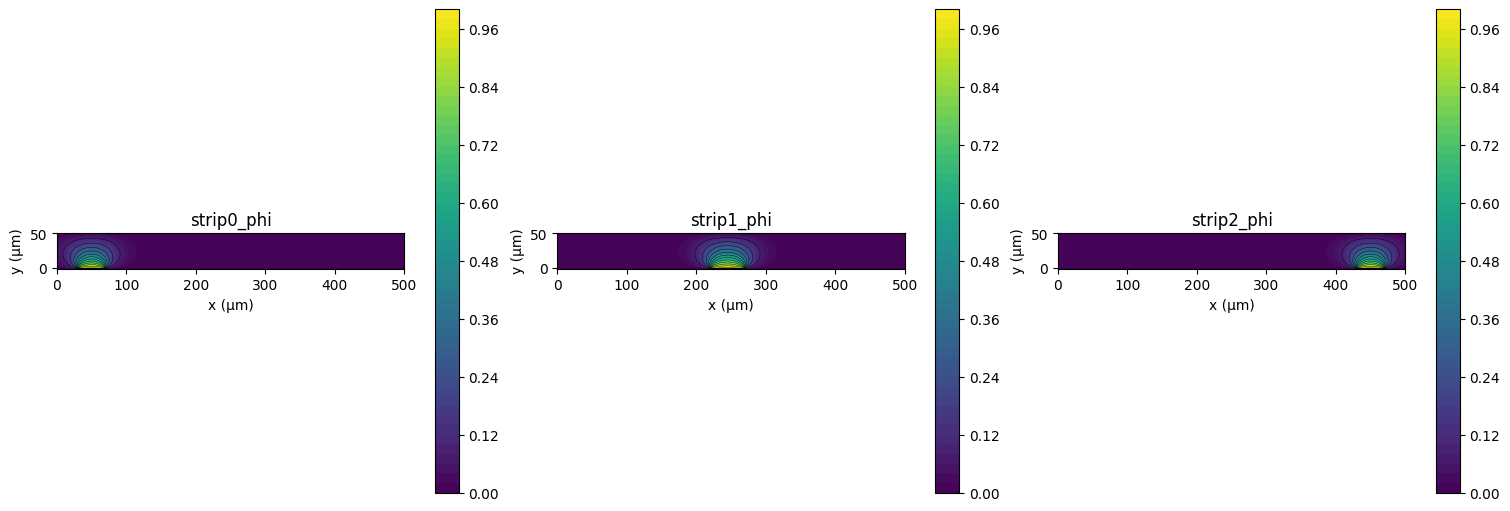

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

for ax, phi in zip(
    axes,
    ["strip0_phi", "strip1_phi", "strip2_phi"]
):
    Z = (
        df.pivot(index="y_um", columns="x_um", values=phi)
          .sort_index()
          .sort_index(axis=1)
          .values
    )

    cf = ax.contourf(X, Y, Z, levels=50, cmap="viridis")
    ax.contour(X, Y, Z, levels=15, colors="k", linewidths=0.3)

    ax.set_title(phi)
    ax.set_xlabel("x (μm)")
    ax.set_ylabel("y (μm)")
    ax.set_aspect("equal")

    plt.colorbar(cf, ax=ax)

plt.show()

In [42]:
ix = np.argmin(np.abs(x - 0))
dphidy, dphidx = np.gradient(Z, y, x)
Ex = -dphidx
Ey = -dphidy

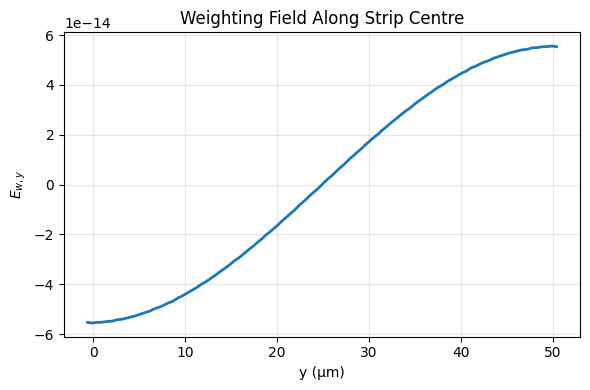

In [43]:
plt.figure(figsize=(6,4))

plt.plot(
    y,
    Ey[:,ix],
    lw=2
)

plt.xlabel("y (μm)")
plt.ylabel(r"$E_{w,y}$")
plt.title("Weighting Field Along Strip Centre")

plt.grid(alpha=0.3)

plt.tight_layout()

In [44]:
try:
    import pylandau
    _HAVE_PYLANDAU = True
except ImportError:
    _HAVE_PYLANDAU = False
try:
    from scipy.optimize import curve_fit
    from scipy.stats import moyal
    _HAVE_SCIPY = True
except ImportError:
    _HAVE_SCIPY = False


def load_overlay(path):
    """signal_overlay*.csv format: time_ns,trk0,trk1,... header,
    optional embedded 'nPairs,...' as line 2, then data rows. Parsed
    manually (not genfromtxt) so a single malformed row can't poison
    the whole load."""
    with open(path) as f:
        lines = f.read().splitlines()
    header = lines[0].split(",")
    ncols = len(header)
    t_idx = header.index("time_ns")
    trk_idx = [i for i, c in enumerate(header) if c.startswith("trk")]
    start = 1
    pairs = None
    if len(lines) > 1 and lines[1].startswith("nPairs"):
        pairs = np.array([float(v) for v in lines[1].split(",")[1:]])
        start = 2
    t_list, sig_rows = [], []
    for ln in lines[start:]:
        if not ln.strip():
            continue
        parts = ln.split(",")
        if len(parts) != ncols:
            continue
        try:
            vals = [float(x) for x in parts]
        except ValueError:
            continue
        if not np.isfinite(vals[t_idx]):
            continue
        t_list.append(vals[t_idx])
        sig_rows.append([vals[i] for i in trk_idx])
    return np.array(t_list), np.array(sig_rows), pairs


def load_silvaco(path, width_um):
    """Same loader as the signal-comparison cell above: s->ns,
    A->uA x width, baseline-subtracted, sign-flipped to match the
    collection convention used everywhere else."""
    silvaco = np.genfromtxt(path, delimiter=",", names=True)
    t_ns = silvaco["Transient_time"] * 1e9
    i_uA = silvaco["Anode_Current"] * 1e6 * width_um
    fired = np.abs(i_uA) > 10 * np.abs(i_uA[0])
    baseline = i_uA[~fired].mean() if (~fired).any() else 0.0
    return t_ns, -(i_uA - baseline)


def fit_langau(charge, bins=80):
    """Landau (x) Gauss fit (pylandau) to a collected-charge sample,
    with a Moyal-distribution fallback (scipy only) if pylandau isn't
    installed. Returns a dict with 'mpv', 'mpv_err', 'curve' (callable),
    or None if there's too little data or the fit doesn't converge."""
    if len(charge) < 20:
        return None
    counts, edges = np.histogram(charge, bins=bins, density=True)
    centers = 0.5 * (edges[1:] + edges[:-1])
    mpv0 = centers[np.argmax(counts)]
    q75, q25 = np.percentile(charge, [75, 25])
    spread0 = max((q75 - q25) / 2, 1e-6)
    if _HAVE_PYLANDAU and _HAVE_SCIPY:
        p0 = [mpv0, spread0 * 0.5, spread0 * 0.3, counts.max()]
        try:
            popt, pcov = curve_fit(
                lambda x, mpv, eta, sigma, A: pylandau.langau(
                    x, mpv, eta, sigma, A),
                centers, counts, p0=p0, maxfev=20000,
                bounds=([0, 1e-3, 1e-3, 0],
                       [np.inf, np.inf, np.inf, np.inf]))
        except RuntimeError:
            return None
        perr = np.sqrt(np.diag(pcov))
        return {"mpv": popt[0], "mpv_err": perr[0], "width": popt[1],
               "curve": lambda x: pylandau.langau(x, *popt),
               "method": "Landau (x) Gauss fit (pylandau)"}
    elif _HAVE_SCIPY:
        try:
            loc, scale = moyal.fit(charge, loc=mpv0, scale=spread0)
        except Exception:
            return None
        return {"mpv": loc, "mpv_err": np.nan, "width": scale,
               "curve": lambda x: moyal.pdf(x, loc, scale),
               "method": "Moyal approximation (scipy; pylandau not "
                         "installed)"}
    return None


t_g, sig_g, pairs_g = load_overlay("signal_overlay150V.csv")

df_q = pd.read_csv("q_150V_current.csv")
t_q = df_q["time_ns"].values
sig_q = df_q.drop(columns=["time_ns"]).values

SILVACO_WIDTH_UM = 1.0
try:
    t_s, i_s = load_silvaco("silvaco150V.csv", SILVACO_WIDTH_UM)
except FileNotFoundError:
    t_s, i_s = None, None
    print("silvaco150V.csv not found -- Silvaco curve skipped where used "
          "below (place the file here and re-run this cell to include it)")

_trap = getattr(np, "trapezoid", None) or np.trapz

print(f"signal_overlay150V (Garfield): {sig_g.shape[1]} tracks, t in "
      f"[{t_g.min():.3g}, {t_g.max():.3g}] ns, nPairs available: "
      f"{pairs_g is not None}")
print(f"q_150V_current (Allpix):       {sig_q.shape[1]} events, t in "
      f"[{t_q.min():.3g}, {t_q.max():.3g}] ns")
if t_s is not None:
    print(f"silvaco150V:                   1 event, t in "
          f"[{t_s.min():.3g}, {t_s.max():.3g}] ns")

signal_overlay150V (Garfield): 200 tracks, t in [0.0025, 4] ns, nPairs available: True
q_150V_current (Allpix):       1000 events, t in [0, 6] ns
silvaco150V:                   1 event, t in [0.001, 4] ns


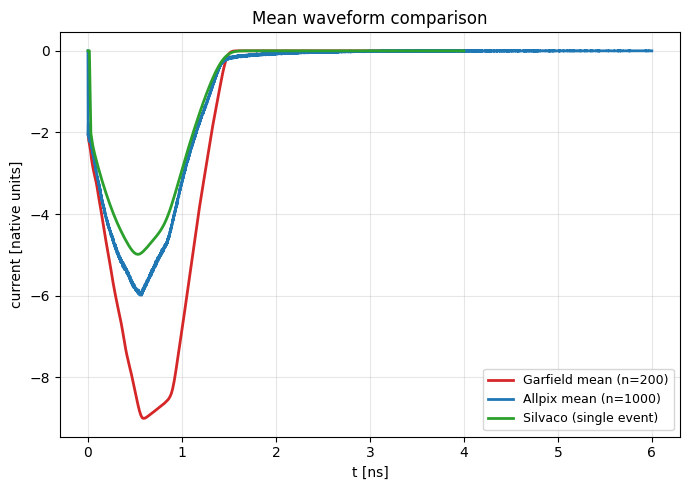

peak of mean -- Garfield: -9.004   Allpix: -5.987   Silvaco: -4.987


In [45]:
mean_g = sig_g.mean(axis=1)
mean_q = sig_q.mean(axis=1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(t_g, mean_g, color="tab:red", lw=2,
       label=f"Garfield mean (n={sig_g.shape[1]})")
ax.plot(t_q, mean_q, color="tab:blue", lw=2,
       label=f"Allpix mean (n={sig_q.shape[1]})")
if t_s is not None:
    ax.plot(t_s, i_s, color="tab:green", lw=2, label="Silvaco (single event)")
ax.set_xlabel("t [ns]")
ax.set_ylabel("current [native units]")
ax.set_title("Mean waveform comparison")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("avg_comparison.png", dpi=150)
plt.show()

print(f"peak of mean -- Garfield: {mean_g[np.argmax(np.abs(mean_g))]:.3f}"
      f"   Allpix: {mean_q[np.argmax(np.abs(mean_q))]:.3f}"
      + (f"   Silvaco: {i_s[np.argmax(np.abs(i_s))]:.3f}" if t_s is not None else ""))

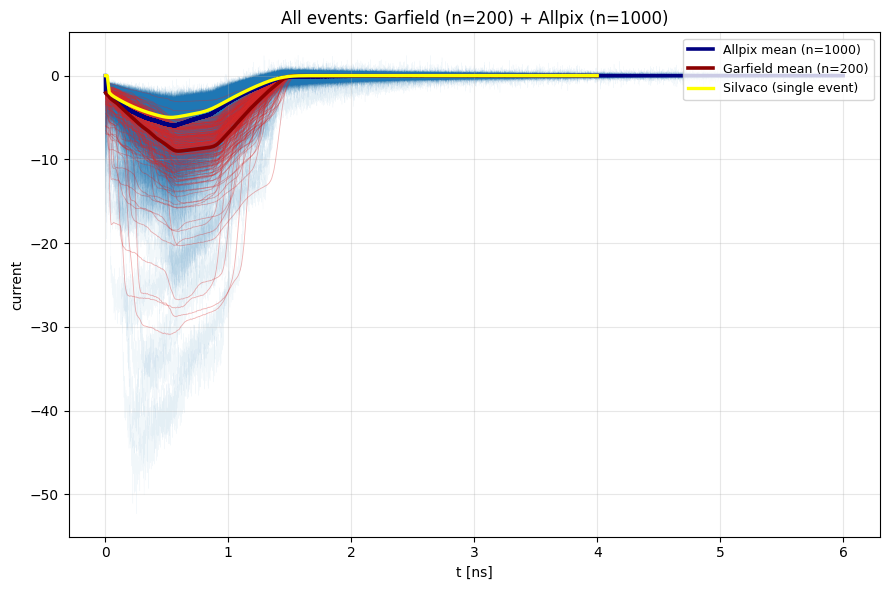

In [54]:
fig, ax = plt.subplots(figsize=(9, 6))
for k in range(sig_q.shape[1]):
    ax.plot(t_q, sig_q[:, k], color="tab:blue", lw=0.3, alpha=0.06, zorder=1)
for k in range(sig_g.shape[1]):
    ax.plot(t_g, sig_g[:, k], color="tab:red", lw=0.6, alpha=0.35, zorder=2)
ax.plot(t_q, mean_q, color="navy", lw=2.6, zorder=3,
       label=f"Allpix mean (n={sig_q.shape[1]})")
ax.plot(t_g, mean_g, color="darkred", lw=2.6, zorder=4,
       label=f"Garfield mean (n={sig_g.shape[1]})")
if t_s is not None:
    ax.plot(t_s, i_s, color="gold", lw=2.4, zorder=5,
           label="Silvaco (single event)")
ax.set_xlabel("t [ns]")
ax.set_ylabel("current")
ax.set_title(f"All events: Garfield (n={sig_g.shape[1]}) + "
             f"Allpix (n={sig_q.shape[1]})")
ax.legend(fontsize=9, loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("all_events_overlay.png", dpi=150)
plt.show()

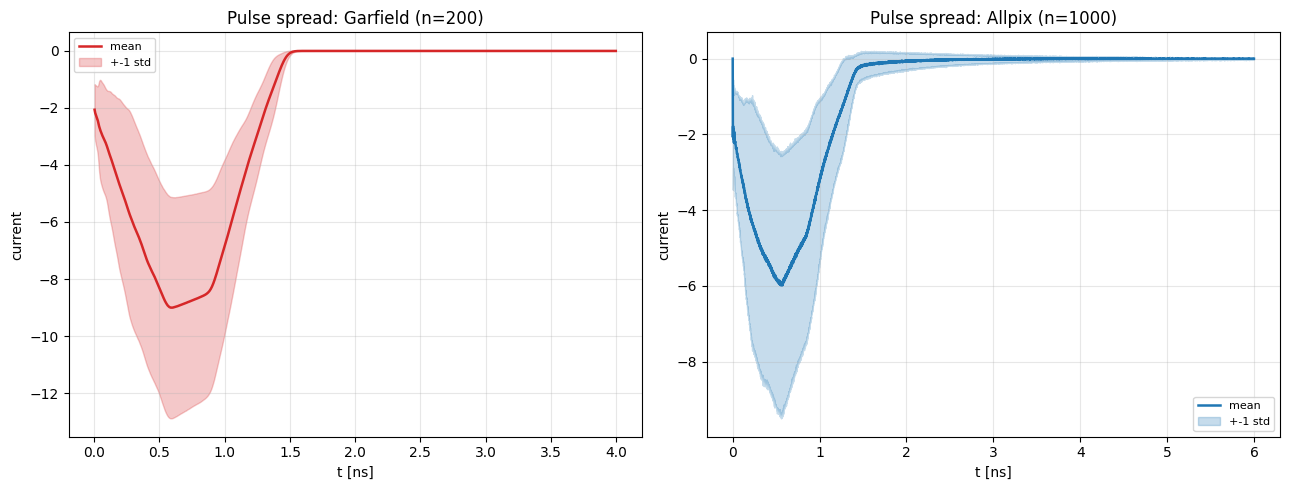

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, t, sig, name, color in [
    (axes[0], t_g, sig_g, "Garfield", "tab:red"),
    (axes[1], t_q, sig_q, "Allpix", "tab:blue"),
]:
    m = sig.mean(axis=1)
    s = sig.std(axis=1)
    ax.plot(t, m, color=color, lw=1.8, label="mean")
    ax.fill_between(t, m - s, m + s, color=color, alpha=0.25, label="+-1 std")
    ax.set_xlabel("t [ns]")
    ax.set_ylabel("current")
    ax.set_title(f"Pulse spread: {name} (n={sig.shape[1]})")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("pulse_spread.png", dpi=150)
plt.show()

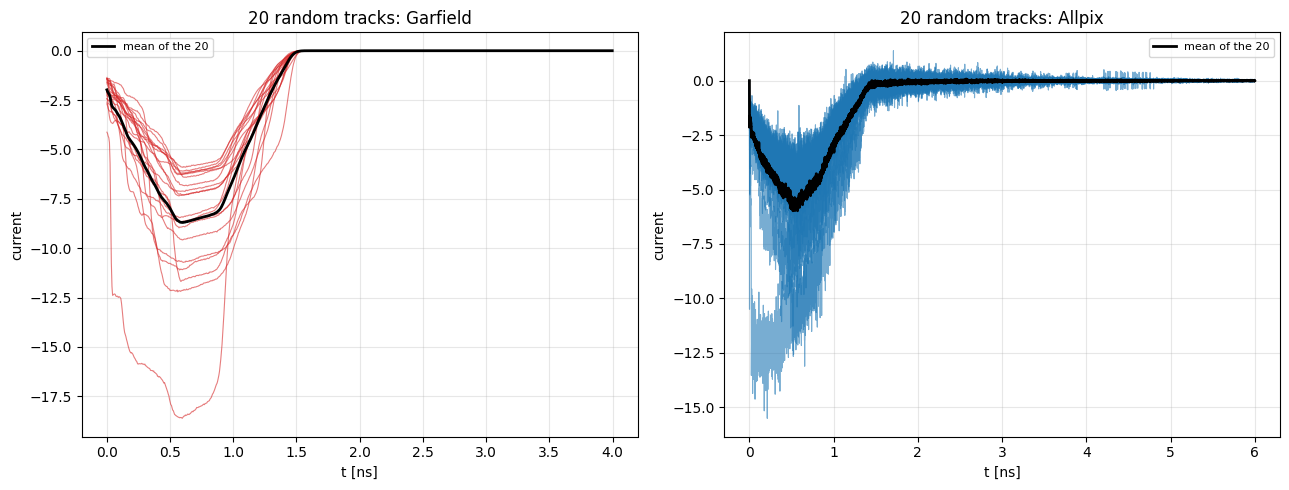

In [48]:
rng = np.random.default_rng(0)  # seeded for reproducibility

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, t, sig, name, color in [
    (axes[0], t_g, sig_g, "Garfield", "tab:red"),
    (axes[1], t_q, sig_q, "Allpix", "tab:blue"),
]:
    idx = rng.choice(sig.shape[1], size=20, replace=False)
    for k in idx:
        ax.plot(t, sig[:, k], color=color, lw=0.8, alpha=0.6)
    ax.plot(t, sig[:, idx].mean(axis=1), color="k", lw=2,
           label="mean of the 20")
    ax.set_xlabel("t [ns]")
    ax.set_ylabel("current")
    ax.set_title(f"20 random tracks: {name}")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("overlay_20random.png", dpi=150)
plt.show()

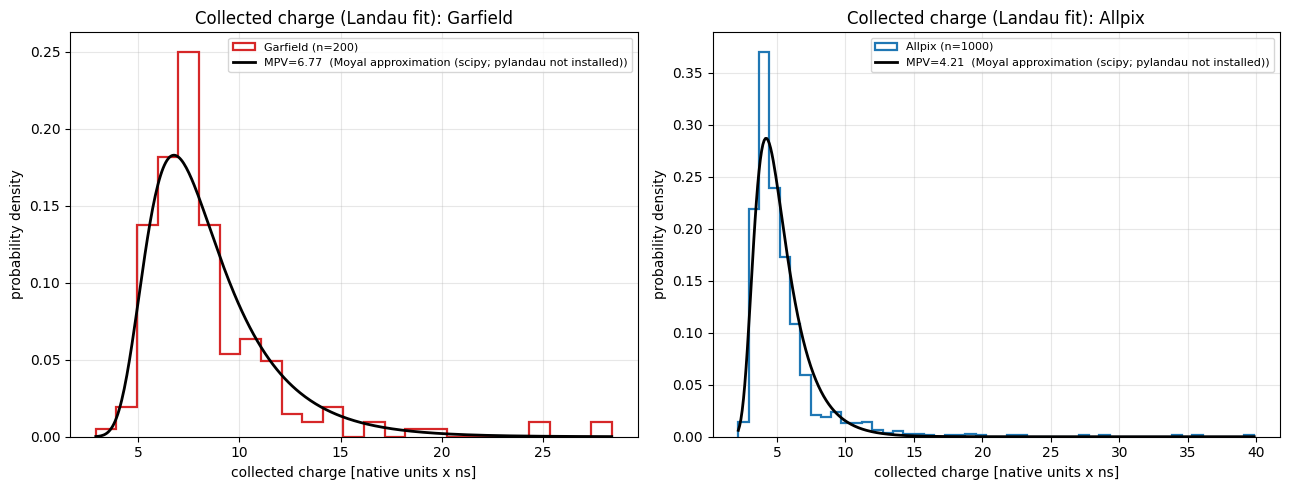

In [ ]:
q_g = np.array([-_trap(sig_g[:, k], t_g) for k in range(sig_g.shape[1])])
q_q = np.array([-_trap(sig_q[:, k], t_q) for k in range(sig_q.shape[1])])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, q, name, color in [
    (axes[0], q_g, "Garfield", "tab:red"),
    (axes[1], q_q, "Allpix", "tab:blue"),
]:
    nbins = min(50, max(15, len(q) // 8))
    ax.hist(q, bins=nbins, histtype="step", lw=1.6, color=color,
           density=True, label=f"{name} (n={len(q)})")
    fit = fit_langau(q, bins=nbins)
    if fit is not None:
        xf = np.linspace(q.min(), q.max(), 400)
        errtxt = f"+-{fit['mpv_err']:.2g}" if np.isfinite(fit["mpv_err"]) \
            else ""
        ax.plot(xf, fit["curve"](xf), color="k", lw=2,
               label=f"MPV={fit['mpv']:.3g}{errtxt}  ({fit['method']})")
    else:
        print(f"{name}: Landau fit unavailable (too little data or no "
              f"convergence) -- histogram only")
    ax.set_xlabel("collected charge [native units x ns]")
    ax.set_ylabel("probability density")
    ax.set_title(f"Collected charge (Landau fit): {name}")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("charge_langau.png", dpi=150)
plt.show()

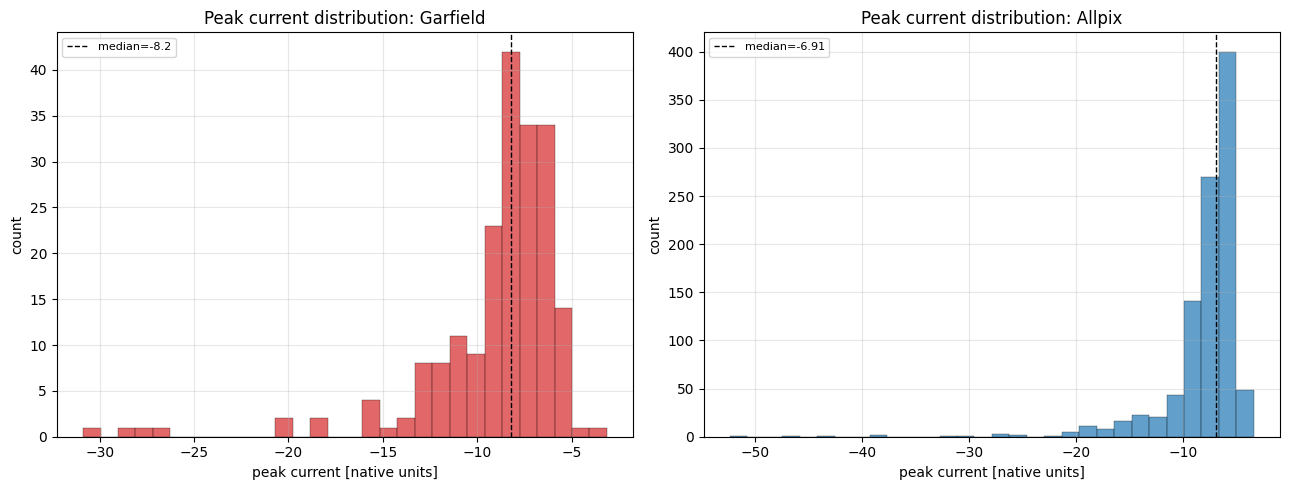

In [50]:
peak_g = np.array([sig_g[np.argmax(np.abs(sig_g[:, k])), k]
                   for k in range(sig_g.shape[1])])
peak_q = np.array([sig_q[np.argmax(np.abs(sig_q[:, k])), k]
                   for k in range(sig_q.shape[1])])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, p, name, color in [
    (axes[0], peak_g, "Garfield", "tab:red"),
    (axes[1], peak_q, "Allpix", "tab:blue"),
]:
    ax.hist(p, bins=30, color=color, alpha=0.7, edgecolor="k", linewidth=0.3)
    ax.axvline(np.median(p), color="k", ls="--", lw=1,
              label=f"median={np.median(p):.3g}")
    ax.set_xlabel("peak current [native units]")
    ax.set_ylabel("count")
    ax.set_title(f"Peak current distribution: {name}")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("peak_current_histogram.png", dpi=150)
plt.show()

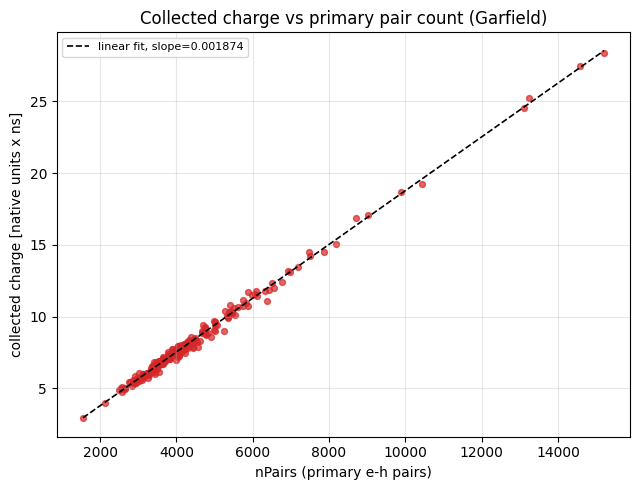

correlation coefficient r = 0.997  (near 1 means gain is roughly constant across tracks -- charge is mostly explained by primary count, not gain scatter)


In [ ]:
if pairs_g is not None:
    fig, ax = plt.subplots(figsize=(6.5, 5))
    ax.scatter(pairs_g, q_g, s=18, alpha=0.7, color="tab:red")
    coef = np.polyfit(pairs_g, q_g, 1)
    xx = np.linspace(pairs_g.min(), pairs_g.max(), 50)
    ax.plot(xx, np.polyval(coef, xx), "k--", lw=1.2,
           label=f"linear fit, slope={coef[0]:.4g}")
    ax.set_xlabel("nPairs (primary e-h pairs)")
    ax.set_ylabel("collected charge [native units x ns]")
    ax.set_title("Collected charge vs primary pair count (Garfield)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("npairs_correlation.png", dpi=150)
    plt.show()
    r = np.corrcoef(pairs_g, q_g)[0, 1]
    print(f"correlation coefficient r = {r:.3f}  "
          f"(near 1 means gain is roughly constant across tracks --"
          f" charge is mostly explained by primary count, not gain scatter)")
else:
    print("no nPairs in signal_overlay150V.csv -- skipping this plot")